In [1]:
# base
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gc
import warnings

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    root_mean_squared_error,
    r2_score,
    mean_absolute_percentage_error,
    median_absolute_error,
    explained_variance_score,
)

# models
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
import joblib

# path
from src.config.path import PROCESS_PATH, MODEL_PATH

In [2]:
warnings.filterwarnings('ignore')

df = pd.read_parquet(PROCESS_PATH /'flight.parquet', engine="pyarrow")
df

,flight,payload,route,altitude_preset,date,time_day,duration_s,total_distance_m,wind_speed_mean,wind_speed_std,...,velocity_mag_max,acceleration_mag_mean,acceleration_mag_std,battery_voltage_mean,battery_voltage_min,max_height_agl,final_height_agl,energy_consumed_Wh,battery_needed_mAh,landing_offset_flag
0,1,0.0,R5,25,2019-04-07,10:13,200.70,549.065984,3.898058,1.952675,...,6.261616,9.842870,0.466372,22.070134,21.228519,26.257755,-0.994409,21.769975,1000.743935,False
1,2,0.0,R5,50,2019-04-07,10:23,271.20,666.615556,3.522941,2.159456,...,7.676739,9.881874,0.628406,21.527547,20.125463,52.637988,0.589477,25.366627,1205.255874,False
2,3,0.0,R5,25,2019-04-07,10:33,180.10,577.009957,4.581182,3.335733,...,7.213987,9.902090,0.545290,22.330305,19.943916,24.660462,0.106140,17.094392,789.073853,False
3,4,0.0,R5,25,2019-04-07,10:48,171.00,562.802357,4.596319,3.438072,...,9.425537,9.900368,0.559073,21.950616,20.365856,25.580572,0.416669,14.690038,687.813976,False
4,5,0.0,R2,25,2019-04-07,11:05,217.00,470.978276,3.333910,2.247522,...,4.900079,9.817243,0.341981,21.519937,18.923494,24.323036,-0.924901,19.019928,920.070980,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
204,275,500.0,R1,25,2019-10-24,9:05,149.40,518.231162,4.139878,3.885389,...,8.788151,9.850903,0.420902,22.056616,20.332052,21.959932,-3.264891,16.295811,760.480643,False
205,276,500.0,R1,25,2019-10-24,9:32,147.90,517.758034,4.392581,4.332293,...,10.553163,9.862172,0.471081,21.492353,19.788662,22.542598,1.293232,15.392088,738.620356,False
206,277,500.0,R1,25,2019-10-24,9:45,134.81,517.677109,5.524651,4.029744,...,10.579715,9.847796,0.529103,21.908016,19.352947,24.289124,-0.286362,15.531389,741.451254,False
207,278,500.0,R7,25-50-100-25,2019-10-24,10:00,186.39,545.413261,4.686967,3.826570,...,10.376503,9.829065,0.456918,22.394109,20.407175,95.041887,-0.457578,18.922540,887.198699,False


In [ ]:
feature_cols = [
    'total_distance_m',      
    'max_height_agl',
    'payload',
    'wind_speed_mean',
    'wind_speed_std',
    'wind_x_mean',
    'wind_y_mean',
    'speed_mean',
    'speed_max',
    'velocity_mag_mean',
    'velocity_mag_max',
    'acceleration_mag_mean',
    'acceleration_mag_std',
]
target = 'energy_consumed_Wh'

PAYLOAD_IDX = feature_cols.index('payload')  # dùng để set monotonic constraint bên dưới

X = df[feature_cols]
y = df[target]

x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

sc = StandardScaler()

x_train_sc = sc.fit_transform(x_train)
x_test_sc = sc.transform(x_test)

x_train_sc.shape, y_train.shape, x_test_sc.shape, y_test.shape

((167, 13), (167,), (42, 13), (42,))

## 1. Model + monotonic constraint theo payload

`monotone_constraints`: 0 = không ràng buộc, +1 = ép output tăng đơn điệu khi feature tăng (giữ các feature khác cố định).
Chỉ set +1 tại vị trí `payload`, các feature còn lại để 0. Ridge/RandomForest/AdaBoost không hỗ trợ tham số này trực tiếp — nếu chọn 1 trong số đó làm model chính thức cho binary search, nhớ vẽ lại đường `predicted_energy` theo `payload` (giữ feature khác cố định) để kiểm tra bằng mắt trước khi dùng.

In [4]:
lr_model = Ridge(
    alpha=0.002866539111078059,
    random_state=42,
)
ada_model = AdaBoostRegressor(
    n_estimators=413,
    learning_rate=0.9789731440027141,
    loss='exponential',
    random_state=42,
)

rf_model = RandomForestRegressor(
    n_estimators=410,
    max_depth=8,
    min_samples_split=5,
    min_samples_leaf=3,
    n_jobs=-1,
    random_state=42,
)

monotone_constraints_list = [0] * len(feature_cols)
monotone_constraints_list[PAYLOAD_IDX] = 1

xgb_model = XGBRegressor(
    max_depth=3,
    learning_rate=0.07161183556408778,
    subsample=0.9699580300221706,
    colsample_bytree=0.8410040190795652,
    reg_alpha=0.8410040190795652,
    reg_lambda=9.888875194983115e-07,
    min_child_weight=2,
    n_estimators=385,
    n_jobs=-1,
    random_state=42,
    monotone_constraints=tuple(monotone_constraints_list),
)

lgbm_model = LGBMRegressor(
    num_leaves=8,
    max_depth=2,
    learning_rate=0.21685220605980327,
    feature_fraction=0.8029048955724699,
    bagging_fraction=0.6529537513693758,
    min_child_samples=3,
    n_estimators=384,
    n_jobs=-1,
    random_state=42,
    verbose=-1,
    monotone_constraints=monotone_constraints_list,
)

lr_model.fit(x_train_sc, y_train)
ada_model.fit(x_train_sc, y_train)
rf_model.fit(x_train_sc, y_train)
xgb_model.fit(x_train_sc, y_train)
lgbm_model.fit(x_train_sc, y_train)

,num_leaves,8
,max_depth,2
,learning_rate,0.21685220605980327
,n_estimators,384
,min_child_samples,3
,random_state,42
,n_jobs,-1
,feature_fraction,0.8029048955724699
,bagging_fraction,0.6529537513693758
,verbose,-1
,monotone_constraints,"[0, 0, ...]"


In [5]:
models = {
    'Linear Regression': lr_model,
    'Ada Boost': ada_model,
    'Random Forest': rf_model,
    'XGBoost': xgb_model,
    'LightGBM': lgbm_model,
}

y_test_arr = np.array(y_test)
pred_table = pd.DataFrame(y_test_arr, columns=['true_val'])
scores = {}
for name, model in models.items():
    print()
    print(name)
    y_pred = model.predict(x_test_sc)
    pred_table[name] = y_pred
    metrics = {
        "MAE": mean_absolute_error(y_test, y_pred),
        "MSE": mean_squared_error(y_test, y_pred),
        "RMSE": root_mean_squared_error(y_test, y_pred),
        "R2": r2_score(y_test, y_pred),
        "MAPE": mean_absolute_percentage_error(y_test, y_pred),
        "MedianAE": median_absolute_error(y_test, y_pred),
        "ExplainedVariance": explained_variance_score(y_test, y_pred),
    }
    scores[name] = metrics["R2"]
    for k, v in metrics.items():
        print(f"{k:<20}: {v:.6f}")


Linear Regression
MAE                 : 1.805599
MSE                 : 5.283663
RMSE                : 2.298622
R2                  : 0.813395
MAPE                : 0.147494
MedianAE            : 1.533091
ExplainedVariance   : 0.813398

Ada Boost
MAE                 : 1.484177
MSE                 : 3.199173
RMSE                : 1.788623
R2                  : 0.887014
MAPE                : 0.081780
MedianAE            : 1.103060
ExplainedVariance   : 0.909436

Random Forest
MAE                 : 1.395119
MSE                 : 3.400914
RMSE                : 1.844157
R2                  : 0.879889
MAPE                : 0.079118
MedianAE            : 0.968665
ExplainedVariance   : 0.881167

XGBoost
MAE                 : 0.940397
MSE                 : 1.703774
RMSE                : 1.305287
R2                  : 0.939827
MAPE                : 0.054532
MedianAE            : 0.634833
ExplainedVariance   : 0.941863

LightGBM
MAE                 : 1.037923
MSE                 : 3.916511
RMSE  

In [6]:
pred_table

,true_val,Linear Regression,Ada Boost,Random Forest,XGBoost,LightGBM
0,19.890924,17.656901,21.448789,21.226095,20.215101,19.873250
1,15.057848,13.881324,16.980594,14.785573,14.988999,14.851744
2,13.081291,13.263443,16.674304,16.437612,14.232068,14.059633
3,16.646359,19.648557,17.696969,16.577740,17.246546,17.671596
4,13.752613,14.733907,16.024613,14.478148,14.448473,14.487658
5,1.238852,4.002987,1.239732,0.786584,0.865816,1.220152
6,28.952001,28.619657,26.999612,28.215291,28.517132,28.825411
7,19.629890,19.664759,21.408943,19.970669,20.040737,20.270918
8,13.011607,11.526052,16.026652,14.634197,13.803345,13.130415
9,18.639668,17.523050,20.525014,20.211782,19.161018,19.551041


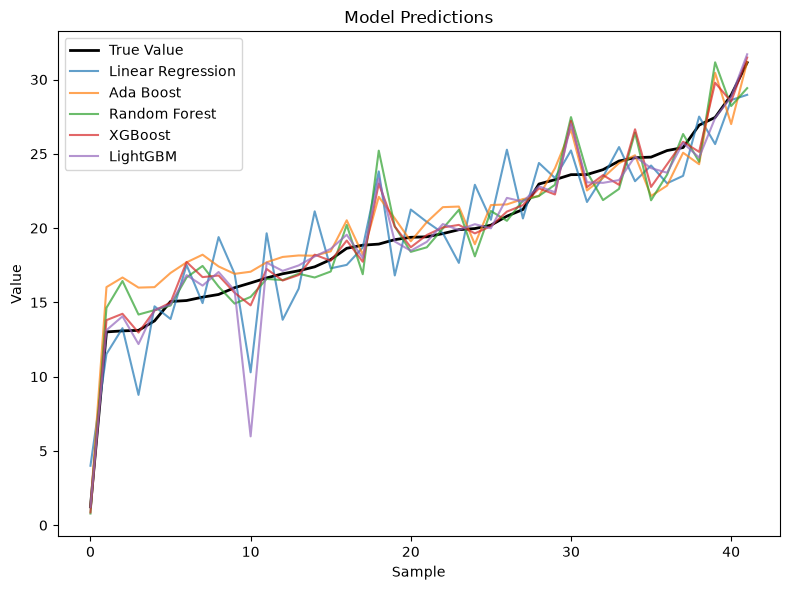

In [7]:
plot_df = pred_table.sort_values('true_val').reset_index(drop=True)

plt.figure(figsize=(8, 6))

plt.plot(plot_df.index, plot_df['true_val'], label='True Value', color='black', linewidth=2)
plt.plot(plot_df.index, plot_df['Linear Regression'], label='Linear Regression', alpha=0.7)
plt.plot(plot_df.index, plot_df['Ada Boost'], label='Ada Boost', alpha=0.7)
plt.plot(plot_df.index, plot_df['Random Forest'], label='Random Forest', alpha=0.7)
plt.plot(plot_df.index, plot_df['XGBoost'], label='XGBoost', alpha=0.7)
plt.plot(plot_df.index, plot_df['LightGBM'], label='LightGBM', alpha=0.7)

plt.xlabel('Sample')
plt.ylabel('Value')
plt.title('Model Predictions')
plt.legend()
plt.tight_layout()
plt.show()

## 2. Kiểm tra tính đơn điệu theo payload (bắt buộc trước khi binary search)

Giữ tất cả feature khác ở giá trị trung bình, chỉ quét `payload` từ 0 → max payload, vẽ `predicted_energy`. Đường phải đi lên đều — nếu gợn sóng/giảm ở đoạn nào, binary search sẽ sai ở đoạn đó.

Model được chọn cho bước binary search: XGBoost (R2 = 0.9398)


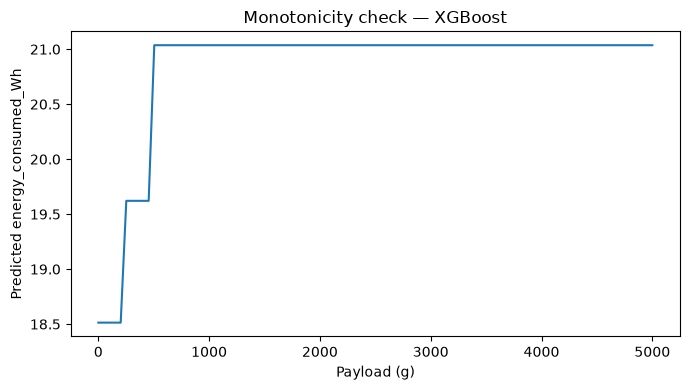

Đơn điệu tăng theo payload: True


In [8]:
best_model_name = max(scores, key=scores.get)
energy_model = models[best_model_name]
print(f"Model được chọn cho bước binary search: {best_model_name} (R2 = {scores[best_model_name]:.4f})")

MAX_PAYLOAD_G = 5000  # tải trọng tối đa của drone (g) — theo yêu cầu

mean_row = X.mean()
sweep_payload = np.linspace(0, MAX_PAYLOAD_G, 100)
sweep_X = pd.DataFrame([mean_row.values] * len(sweep_payload), columns=feature_cols)
sweep_X['payload'] = sweep_payload
sweep_pred = energy_model.predict(sc.transform(sweep_X))

plt.figure(figsize=(7, 4))
plt.plot(sweep_payload, sweep_pred)
plt.xlabel('Payload (g)')
plt.ylabel('Predicted energy_consumed_Wh')
plt.title(f'Monotonicity check — {best_model_name}')
plt.tight_layout()
plt.show()

is_monotonic = np.all(np.diff(sweep_pred) >= -1e-9)
print('Đơn điệu tăng theo payload:', is_monotonic)

In [9]:
# lưu artifact: model + scaler + feature list (khớp với feature set dùng lúc inference)
joblib.dump(
    {
        'model': energy_model,
        'model_name': best_model_name,
        'scaler': sc,
        'features': feature_cols,
        'target': target,
    },
    MODEL_PATH / 'energy_model.pkl',
)

['/home/dangle/code/drone/models/energy_model.pkl']

## 3. Binary search tìm max feasible payload

`energy_model` đã train ở trên được dùng làm **oracle** — không giải ngược phương trình.
`usable_capacity = battery_remaining_Wh × safety_factor` (mặc định safety_factor = 0.85, nằm trong khoảng 80–90% theo đề xuất).

Toàn bộ dữ liệu pin/route ở phần này là **bản copy mô phỏng**, không đụng vào `df` gốc.

In [ ]:
SAFETY_FACTOR = 0.85
DEFAULT_BATTERY_WH = 120.0 
EPSILON_G = 10.0  # độ chính xác binary search (gram)


def predict_energy_wh(route_features: dict, payload_g: float, model, scaler, feature_cols):
    """Gọi energy_model như 1 oracle: input = route/wind/speed cố định + 1 giá trị payload ứng viên."""
    row = {**route_features, 'payload': payload_g}
    x = pd.DataFrame([row], columns=feature_cols)
    x_sc = scaler.transform(x)
    return model.predict(x_sc)[0]


def max_feasible_payload(
    route_features: dict,
    usable_capacity_wh: float,
    model,
    scaler,
    feature_cols,
    max_payload_g: float = MAX_PAYLOAD_G,
    epsilon_g: float = EPSILON_G,
):
    """Binary search payload lớn nhất mà energy dự đoán vẫn <= usable_capacity_wh.
    Yêu cầu: predicted_energy phải tăng đơn điệu theo payload (đã kiểm tra ở bước 3).
    Trả về payload=0 nếu ngay cả không tải cũng vượt pin (route bị loại khỏi bước phân bổ).
    """
    lo, hi = 0.0, max_payload_g
    energy_at_zero = predict_energy_wh(route_features, 0.0, model, scaler, feature_cols)
    if energy_at_zero > usable_capacity_wh:
        return 0.0

    best = 0.0
    while hi - lo > epsilon_g:
        mid = (lo + hi) / 2
        predicted_energy = predict_energy_wh(route_features, mid, model, scaler, feature_cols)
        if predicted_energy <= usable_capacity_wh:
            best = mid
            lo = mid
        else:
            hi = mid
    return best

## 4. Route profile & mô phỏng đội drone (bản copy — không ghi đè `df`)

`route_profile`: giá trị trung bình các feature (trừ `payload`) theo từng `route`, đại diện cho đặc tính đã biết trước của route đó (distance, wind, speed...).

`drones_sim`: bảng giả lập pin còn lại của từng drone — mặc định `DEFAULT_BATTERY_WH` cho mọi drone vì hiện chưa có dữ liệu pin thực tế. Đây là **copy độc lập**, khi có dữ liệu pin thật ngoài thực tế chỉ cần thay bảng này, không đụng vào `df` gốc.

In [11]:
route_feature_cols = [c for c in feature_cols if c != 'payload']

# .copy() tường minh để đảm bảo không vô tình ghi đè lại df gốc ở các cell sau
route_profile = df.groupby('route')[route_feature_cols].mean().reset_index().copy()
route_profile

,route,total_distance_m,max_height_agl,wind_speed_mean,wind_speed_std,wind_x_mean,wind_y_mean,speed_mean,speed_max,velocity_mag_mean,velocity_mag_max,acceleration_mag_mean,acceleration_mag_std
0,A1,0.000000,0.000000,0.125747,0.052051,0.047192,-0.105207,0.000000,0.000000,0.000000,0.000000,9.811154,0.001353
1,A2,0.000000,0.000000,0.105483,0.052286,0.046656,-0.076634,0.000000,0.000000,0.000000,0.000000,9.808860,0.007383
2,A3,0.000000,0.000000,0.264174,0.103143,0.158582,-0.071858,0.000000,0.000000,0.000000,0.000000,9.805653,0.012336
3,H,29.915982,1.476263,2.302309,0.856885,-0.478543,1.518124,0.000000,0.000000,0.156798,0.888215,9.800223,0.217482
4,R1,591.375205,63.293994,4.533689,3.405961,-0.309808,0.276390,8.076923,8.076923,3.186730,8.704013,9.847515,0.454679
5,R2,470.978276,24.323036,3.333910,2.247522,0.062744,-1.257258,4.000000,4.000000,2.126439,4.900079,9.817243,0.341981
6,R3,510.408867,23.956853,4.027639,1.984228,-0.663277,-1.925686,4.000000,4.000000,2.460691,4.695819,9.818944,0.405260
7,R4,514.360282,24.334457,4.884712,1.887051,-1.998105,1.317073,4.000000,4.000000,2.818824,4.912380,9.823863,0.434394
8,R5,588.873464,32.284194,4.149625,2.721484,0.003351,-1.575097,5.500000,5.500000,2.835146,7.644470,9.881800,0.549785
9,R6,911.304126,38.815090,5.253920,3.814737,1.716795,-1.730805,8.400000,8.400000,3.861119,9.012599,9.851359,0.435210


In [12]:
def simulate_fleet(drone_ids, default_capacity_wh: float = DEFAULT_BATTERY_WH):
    """Tạo bảng pin còn lại giả lập cho từng drone. Copy độc lập, không đụng vào df gốc.
    Khi có dữ liệu pin thật, chỉ cần thay hàm này bằng nguồn dữ liệu thực (API/telemetry),
    phần binary search phía trên không cần đổi gì.
    """
    return pd.DataFrame({
        'drone_id': drone_ids,
        'battery_remaining_wh': [22,23,24,25,26],
    }).copy()


drones_sim = simulate_fleet(drone_ids=['drone_1', 'drone_2', 'drone_3', 'drone_4', 'drone_5'])
drones_sim

,drone_id,battery_remaining_wh
0,drone_1,22
1,drone_2,23
2,drone_3,24
3,drone_4,25
4,drone_5,26


## 5. Ma trận `max_feasible_payload(drone, route)`

Với mỗi cặp (drone, route): lấy `battery_remaining_wh` của drone → `usable_capacity`, lấy route features từ `route_profile`, chạy binary search. Route nào cho payload = 0 nghĩa là ngay cả bay không tải cũng vượt pin → loại khỏi bước phân bổ.

In [13]:
records = []
for _, drone in drones_sim.iterrows():
    usable_capacity_wh = drone['battery_remaining_wh'] * SAFETY_FACTOR
    for _, route in route_profile.iterrows():
        route_features = route[route_feature_cols].to_dict()
        payload = max_feasible_payload(
            route_features=route_features,
            usable_capacity_wh=usable_capacity_wh,
            model=energy_model,
            scaler=sc,
            feature_cols=feature_cols,
        )
        records.append({
            'drone_id': drone['drone_id'],
            'route': route['route'],
            'usable_capacity_wh': usable_capacity_wh,
            'max_feasible_payload_g': payload,
            'feasible': payload > 0,
        })

feasibility_matrix = pd.DataFrame(records)
feasibility_matrix.pivot(index='drone_id', columns='route', values='max_feasible_payload_g')

route,A1,A2,A3,H,R1,R2,R3,R4,R5,R6,R7
drone_id,,,,,,,,,,,
drone_1,4990.234375,4990.234375,4990.234375,244.140625,244.140625,0.000000,0.000000,0.000000,0.000000,0.000000,498.046875
drone_2,4990.234375,4990.234375,4990.234375,498.046875,498.046875,244.140625,0.000000,0.000000,0.000000,244.140625,4990.234375
drone_3,4990.234375,4990.234375,4990.234375,498.046875,498.046875,244.140625,0.000000,0.000000,244.140625,244.140625,4990.234375
drone_4,4990.234375,4990.234375,4990.234375,4990.234375,4990.234375,244.140625,244.140625,0.000000,498.046875,498.046875,4990.234375
drone_5,4990.234375,4990.234375,4990.234375,4990.234375,4990.234375,498.046875,244.140625,244.140625,4990.234375,498.046875,4990.234375


## 6. Phân bổ đơn hàng (package) vào từng drone theo route — Bin Packing

Input của bước này là danh sách đơn hàng thực tế `(order_id, route, weight_kg)`, và `feasibility_matrix` đã tính ở bước 6
(cặp `drone_id`–`route` nào chở được bao nhiêu gram tối đa).

Mục tiêu: với mỗi `route`, xếp các đơn hàng vào drone sao cho **tải trọng mỗi drone tiệm cận sát nhất**
`max_feasible_payload_g` của nó (tận dụng tối đa pin đã tính), và nếu tổng khối lượng đơn hàng của 1 route
vượt quá 1 drone thì tự động dùng thêm drone thứ 2, thứ 3...

Thuật toán dùng: **Best-Fit Decreasing (BFD)** — biến thể bin packing.
- Sắp đơn hàng giảm dần theo cân nặng (gói nặng xếp trước để tránh kẹt ở cuối).
- Sắp danh sách drone khả dụng của route đó giảm dần theo `max_feasible_payload_g`
  (drone chở khỏe nhất — tức còn nhiều pin nhất — được ưu tiên dùng trước).
- Với mỗi đơn hàng: tìm trong các drone **đã mở** drone nào còn dư tải trọng **ít nhất mà vẫn đủ chỗ**
  (best-fit) → giúp tải trọng cuối cùng của drone đó sát trần nhất có thể.
- Nếu không drone nào đang mở đủ chỗ → mở thêm 1 drone mới (theo thứ tự pin khỏe nhất còn lại).
- Nếu hết drone khả dụng của route mà vẫn còn đơn chưa xếp được → đơn đó rơi vào `unassigned`
  (cần điều drone từ route khác, sạc thêm pin, hoặc tách nhỏ đơn hàng).

In [14]:
def bin_pack_route(route_name, packages_g, feasibility_matrix, epsilon_g=EPSILON_G):
    """
    packages_g : list[tuple(order_id, weight_g)] — đơn hàng của 1 route.
    feasibility_matrix : output bước 6 (cột drone_id, route, max_feasible_payload_g, feasible).

    Trả về:
        assignments : list[dict] — mỗi dict là 1 đơn hàng đã gán cho 1 drone cụ thể.
        unassigned  : list[order_id] — đơn hàng không drone nào của route này chở nổi.
    """
    avail = (
        feasibility_matrix[
            (feasibility_matrix['route'] == route_name) & (feasibility_matrix['feasible'])
        ]
        .sort_values('max_feasible_payload_g', ascending=False)
        .reset_index(drop=True)
    )
    if avail.empty:
        return [], [oid for oid, _ in packages_g]

    packages_sorted = sorted(packages_g, key=lambda x: x[1], reverse=True)
    max_capacity = avail['max_feasible_payload_g'].max()

    open_bins = []       # drone đã được mở dùng cho route này: list[dict(drone_id, remaining_g)]
    next_drone_idx = 0    # con trỏ trong `avail`, mở drone khỏe nhất còn lại trước
    assignments, unassigned = [], []

    def open_next_bin():
        nonlocal next_drone_idx
        if next_drone_idx >= len(avail):
            return None
        row = avail.iloc[next_drone_idx]
        next_drone_idx += 1
        bin_ = {'drone_id': row['drone_id'], 'remaining_g': row['max_feasible_payload_g']}
        open_bins.append(bin_)
        return bin_

    for order_id, w in packages_sorted:
        if w <= 0:
            continue
        if w > max_capacity + epsilon_g:
            # không drone nào (kể cả rỗng) của route này chở nổi 1 mình đơn hàng này
            unassigned.append(order_id)
            continue

        # best-fit: trong các bin đang mở, chọn bin dư ÍT NHẤT nhưng vẫn đủ chỗ
        candidates = [b for b in open_bins if b['remaining_g'] >= w]
        if candidates:
            target = min(candidates, key=lambda b: b['remaining_g'])
        else:
            target = open_next_bin()
            while target is not None and target['remaining_g'] < w:
                target = open_next_bin()
            if target is None:
                unassigned.append(order_id)
                continue

        target['remaining_g'] -= w
        assignments.append({
            'order_id': order_id,
            'route': route_name,
            'weight_g': w,
            'drone_id': target['drone_id'],
        })

    return assignments, unassigned

## 7. Chạy phân bổ cho toàn bộ đơn hàng (nhiều route cùng lúc)

`orders` là ví dụ minh hoạ — thực tế thay bằng bảng đơn hàng thật (từ hệ thống nhận đơn), chỉ cần đủ 3 cột
`order_id`, `route`, `weight_kg`.

In [15]:
orders = pd.DataFrame([
    {'order_id': 'ORD001', 'route': route_profile['route'].iloc[0], 'weight_kg': 1.2},
    {'order_id': 'ORD002', 'route': route_profile['route'].iloc[0], 'weight_kg': 2.8},
    {'order_id': 'ORD003', 'route': route_profile['route'].iloc[0], 'weight_kg': 0.9},
    {'order_id': 'ORD004', 'route': route_profile['route'].iloc[0], 'weight_kg': 3.5},
    {'order_id': 'ORD005', 'route': route_profile['route'].iloc[-1], 'weight_kg': 1.5},
    {'order_id': 'ORD006', 'route': route_profile['route'].iloc[-1], 'weight_kg': 2.0},
])
orders['weight_g'] = orders['weight_kg'] * 1000

all_assignments, all_unassigned = [], []

for route_name, group in orders.groupby('route'):
    pkgs = list(zip(group['order_id'], group['weight_g']))
    assigns, unassigned = bin_pack_route(route_name, pkgs, feasibility_matrix)
    all_assignments.extend(assigns)
    all_unassigned.extend(unassigned)

assignment_table = pd.DataFrame(all_assignments)
assignment_table

,order_id,route,weight_g,drone_id
0,ORD004,A1,3500.0,drone_1
1,ORD002,A1,2800.0,drone_2
2,ORD001,A1,1200.0,drone_1
3,ORD003,A1,900.0,drone_2
4,ORD006,R7,2000.0,drone_2
5,ORD005,R7,1500.0,drone_2


## 8. Bảng tổng hợp: mỗi drone sau khi phân bổ đã chở bao nhiêu % so với trần pin cho phép

`utilization_pct` càng gần 100% nghĩa là thuật toán best-fit đã tận dụng pin của drone đó càng sát mức tối đa an toàn
(`usable_capacity_wh` = `battery_remaining_wh × SAFETY_FACTOR`.

In [16]:
summary = (
    assignment_table.groupby(['route', 'drone_id'])
    .agg(total_weight_g=('weight_g', 'sum'), n_packages=('order_id', 'count'))
    .reset_index()
    .merge(feasibility_matrix[['route', 'drone_id', 'max_feasible_payload_g']], on=['route', 'drone_id'])
)
summary['utilization_pct'] = (summary['total_weight_g'] / summary['max_feasible_payload_g'] * 100).round(1)
summary = summary.sort_values(['route', 'utilization_pct'], ascending=[True, False]).reset_index(drop=True)
summary

,route,drone_id,total_weight_g,n_packages,max_feasible_payload_g,utilization_pct
0,A1,drone_1,4700.0,2,4990.234375,94.2
1,A1,drone_2,3700.0,2,4990.234375,74.1
2,R7,drone_2,3500.0,2,4990.234375,70.1


In [17]:
print(f"Số đơn hàng KHÔNG có drone nào (của route đó) chở nổi: {len(all_unassigned)}")
all_unassigned

Số đơn hàng KHÔNG có drone nào (của route đó) chở nổi: 0


[]

In [ ]:
del df
gc.collect()
%whos